In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv("listings.csv")

df.head()


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,35528477,Bedroom,173395026,Brian,Dublin City Council,Clontarf LEA-6,53.37897,-6.23616,Private room,NaN,1,0,NaN,NaN,1,0,0,NaN
1,4304166,City Centre Apartment,22295110,Andrew,Dublin City Council,North Inner City LEA-7,53.34876,-6.27156,Private room,NaN,500,0,NaN,NaN,2,0,0,NaN
2,18504119,Beside UCD,67362903,Julie,Dublin City Council,Pembroke LEA-5,53.31230,-6.22145,Entire home/apt,NaN,14,0,NaN,NaN,1,0,0,NaN
3,38456538,Quiet room close to the city centre,187860224,Moe,Dublin City Council,North Inner City LEA-7,53.35041,-6.24410,Private room,NaN,1,9,2019-11-03,0.12,1,0,0,NaN
4,15784729,Cozy single room with spare bathroom,102100524,Eliot,Dublin City Council,South West Inner City LEA-5,53.34029,-6.28079,Private room,NaN,2,1,2016-11-17,0.01,1,0,0,NaN


In [6]:
df.shape

(32665, 18)

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

In [11]:
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,7
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,6845


In [13]:
df["price"].head(20)
df["price"].dtype

dtype('float64')

In [14]:
airbnb = df.copy()

airbnb = airbnb.dropna(subset=["price"])

In [15]:
airbnb["price"].isnull().sum()

np.int64(0)

In [16]:
airbnb.shape

(25820, 18)

In [17]:
airbnb["price"].describe()

,price
count,25820.000000
mean,275.094578
std,1735.242095
min,11.000000
25%,93.000000
50%,133.000000
75%,200.000000
max,50000.000000


In [18]:
airbnb["price"].sort_values(ascending=False).head(20)

,price
17125,50000.0
17260,50000.0
29508,50000.0
17151,50000.0
9857,45000.0
17164,40000.0
29517,40000.0
17144,40000.0
17252,40000.0
29689,40000.0


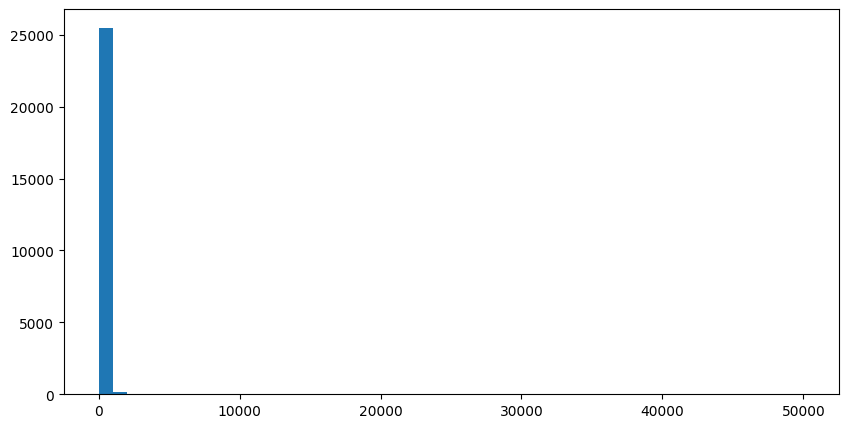

In [20]:
plt.figure(figsize=(10,5))
plt.hist(airbnb["price"], bins=50)
plt.show()

In [22]:
airbnb[airbnb["price"]>1000].shape

(323, 18)

In [24]:
airbnb[airbnb["price"] > 1000]["price"].describe()

,price
count,323.000000
mean,8625.151703
std,13012.641122
min,1003.000000
25%,1250.000000
50%,1776.000000
75%,8000.000000
max,50000.000000


In [25]:
airbnb = airbnb[airbnb["price"] <= 1000]
airbnb.shape
airbnb["price"].describe()

,price
count,25497.000000
mean,169.314743
std,127.248598
min,11.000000
25%,92.000000
50%,132.000000
75%,198.000000
max,1000.000000


In [26]:
airbnb.to_csv("listings_clean.csv", index=False)

**How many Airbnb listings are there in each area?**

In [27]:
airbnb["neighbourhood"].value_counts().head(10)

,count
neighbourhood,
Kenmare LEA-6,1107
North Inner City LEA-7,974
Ennistimon LEA-4,821
South East Inner City LEA-5,788
Conamara North LEA-4,783
Corca Dhuibhne LEA-3,747
Glenties LEA-6,712
Donegal LEA-6,635
Bantry-West Cork LEA-4,617


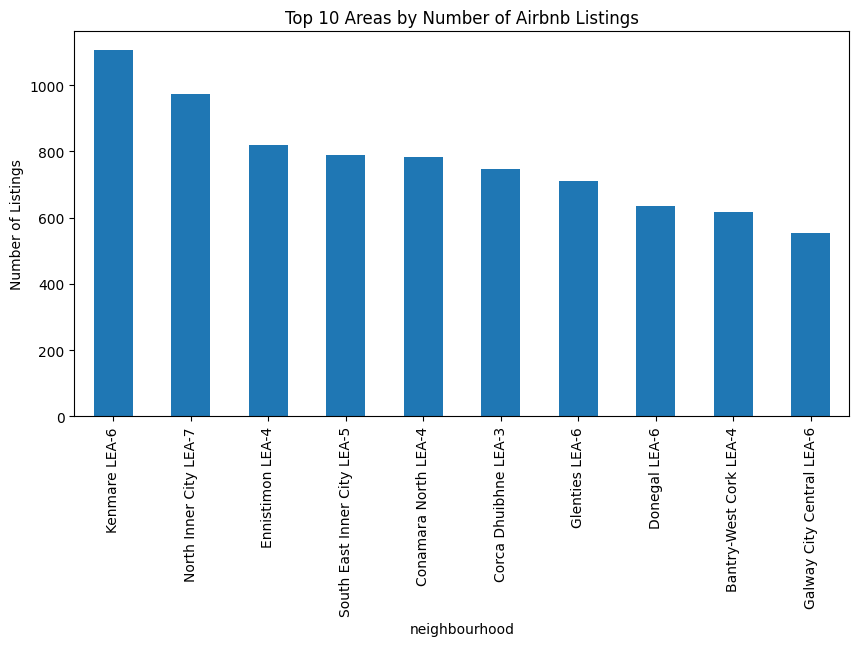

In [33]:
top_areas = airbnb["neighbourhood"].value_counts().head(10)

top_areas.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Areas by Number of Airbnb Listings")
plt.ylabel("Number of Listings")
plt.show()

Kenmare LEA-6 and North Inner City LEA-7 have the highest concentration of Airbnb listings, indicating strong tourism demand and a highly competitive short-term rental market.

**Which areas are the most expensive?**

In [28]:
airbnb.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

,price
neighbourhood,
South East Inner City LEA-5,263.602792
Dundalk-Carlingford LEA-6,257.595092
Pembroke LEA-5,256.347458
Greystones LEA-6,233.767442
Galway City Central LEA-6,221.822785
Blackrock LEA-6,215.425000
North Inner City LEA-7,214.637577
Clontarf LEA-6,211.030612
Carrick-on-Shannon LEA-6,208.747967


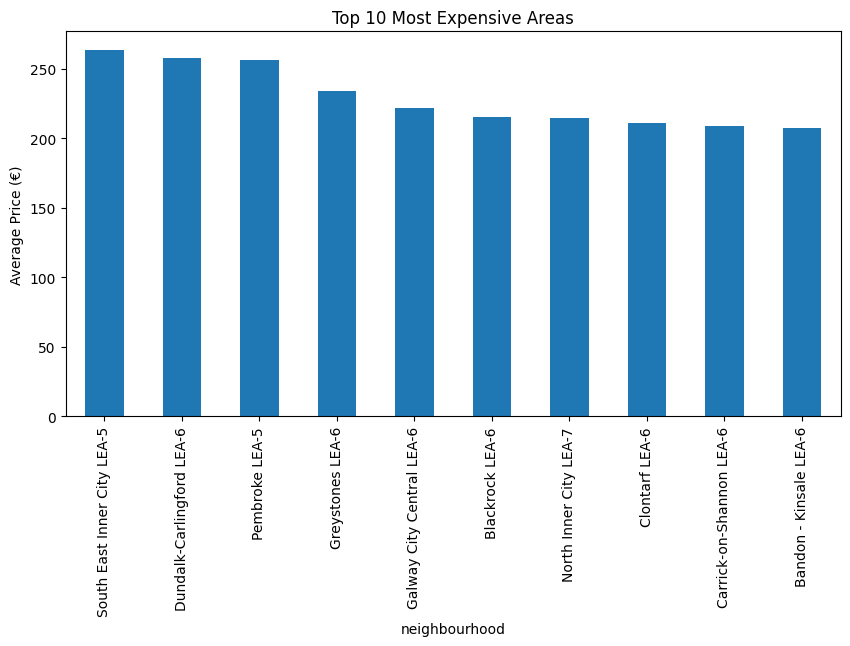

In [35]:
expensive = airbnb.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)

expensive.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Most Expensive Areas")
plt.ylabel("Average Price (€)")
plt.show()

South East Inner City LEA-5 is the most expensive Airbnb market in Ireland with an average nightly price of approximately €264.

**What types of housing are the most popular?**

In [29]:
airbnb["room_type"].value_counts()

,count
room_type,
Entire home/apt,17850
Private room,7459
Shared room,123
Hotel room,65


Entire homes and apartments dominate the Irish Airbnb market, accounting for the vast majority of listings

**What is the average price by type of housing?**

Entire homes generate significantly higher nightly rates than private rooms, suggesting that hosts can charge a premium for offering an entire property.

In [30]:
airbnb.groupby("room_type")["price"].mean().sort_values(ascending=False)

,price
room_type,
Entire home/apt,196.607003
Hotel room,168.861538
Private room,105.426867
Shared room,83.154472


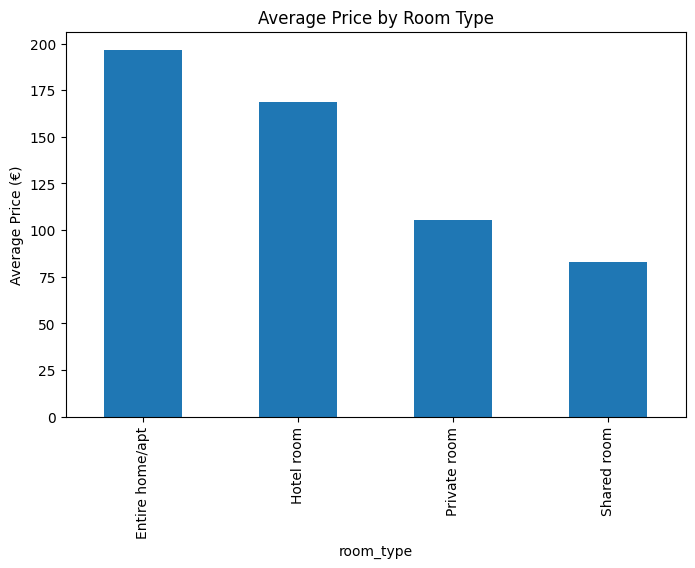

In [34]:
room_price = airbnb.groupby("room_type")["price"].mean()

room_price.plot(kind="bar", figsize=(8,5))

plt.title("Average Price by Room Type")
plt.ylabel("Average Price (€)")
plt.show()

**Which areas get the most reviews?**

In [31]:
airbnb.groupby("neighbourhood")["number_of_reviews"].mean().sort_values(ascending=False).head(10)

,number_of_reviews
neighbourhood,
Galway City Central LEA-6,137.177215
Piltown LEA-5,130.750000
Killarney LEA-7,121.414179
Kilkenny LEA-7,119.261905
Gort-Kinvara LEA-5,107.780702
Cork City North West LEA-6,106.431373
Limerick City North LEA-7,103.439024
Bandon - Kinsale LEA-6,102.851613
Athlone LEA-5,102.016393


Listings in Galway City Central LEA-6 receive the highest average number of reviews, suggesting strong guest demand and high occupancy levels.